# Homework

## Problem 1

Let $f(x) = 2\sin x - \cos{2x}$. Write a function `beauty_derivative_plot` that takes a point $x$ and plots the function $f(x)$ and its derivative $f'(x)$ in the range $x \in [-2\pi, 2\pi]$. The function should also plot the tangent line to the function at the point $x$. 

Example of output for $x = -3, -2, 1.7$:

```python
beauty_derivative_plot(-3)
```
<img src="https://i.ibb.co/zTdYLC0J/tangent-line-3-0.png" width="600"/>

```python
beauty_derivative_plot(-2)
```
<img src="https://i.ibb.co/hFXNZ7wS/tangent-line-2-0.png" width="600"/>

```python
beauty_derivative_plot(1.7)
```
<img src="https://i.ibb.co/217yHstn/tangent-line-1-7.png" width="600"/>

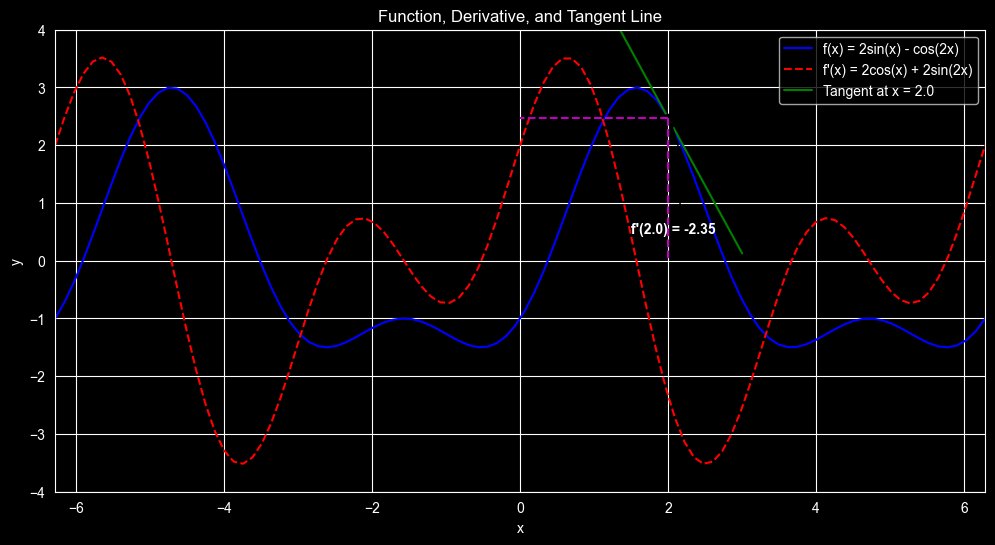

In [13]:
import matplotlib.pyplot as plt
import numpy as np

def beauty_derivative_plot(my_x):
    plt.figure(figsize = (12, 6))
    x = np.linspace(-2 * np.pi, 2 * np.pi, 100)
    f1 = lambda x : 2 * np.sin(x) - np.cos(2 * x)
    f2 = lambda x: 2 * np.cos(x) + 2 * np.sin(2 * x)
    my_y = f1(my_x)
    my_y_div = f2(my_x)
    x_line = np.linspace(my_x - 1, my_x + 1, 100)
    y_line = my_y +my_y_div * (x_line - my_x)

    plt.grid(True)
    plt.xlim(-2 * np.pi, 2 * np.pi)
    plt.ylim(-4, 4)
    plt.plot(x, f1(x), "b-", label = "f(x) = 2sin(x) - cos(2x)")
    plt.plot(x, f2(x), "r--", label = "f'(x) = 2cos(x) + 2sin(2x)")
    plt.plot(x_line, y_line, "g-", label = f"Tangent at x = {my_x}")
    plt.plot(my_x, my_y, "ko")
    plt.plot([my_x, my_x], [my_y, 0], "m--")
    plt.plot([my_x, 0], [my_y, my_y], "m--")
    plt.annotate(f"f'({my_x}) = {round(f2(my_x), 2)}", xy=(my_x, my_y), xytext=(my_x - 0.5, my_y - 2),
                fontweight = "bold", arrowprops = dict(arrowstyle = "-|>", color = "black", lw = 1,
                connectionstyle = "arc3, rad = 0.2"))
    plt.legend(loc = "upper right")
    plt.title("Function, Derivative, and Tangent Line")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()

point = np.double(input())
if point <= 2 * np.pi and point >= -2 * np.pi:
    beauty_derivative_plot(point)
else:
    print("Choose another point!")

## Problem 2

The data in [populations.txt](http://www.scipy-lectures.org/_downloads/populations.txt) describes the populations of hares, lynxes and carrots in northern Canada during 20 years. Get the data with 
```python
np.loadtxt('http://www.scipy-lectures.org/_downloads/populations.txt')
```
and do the following exercises **without for-loops (!!!)**.

- Plot the population size of each species for each year on a single graph. Add legend and axis labels to the plot.

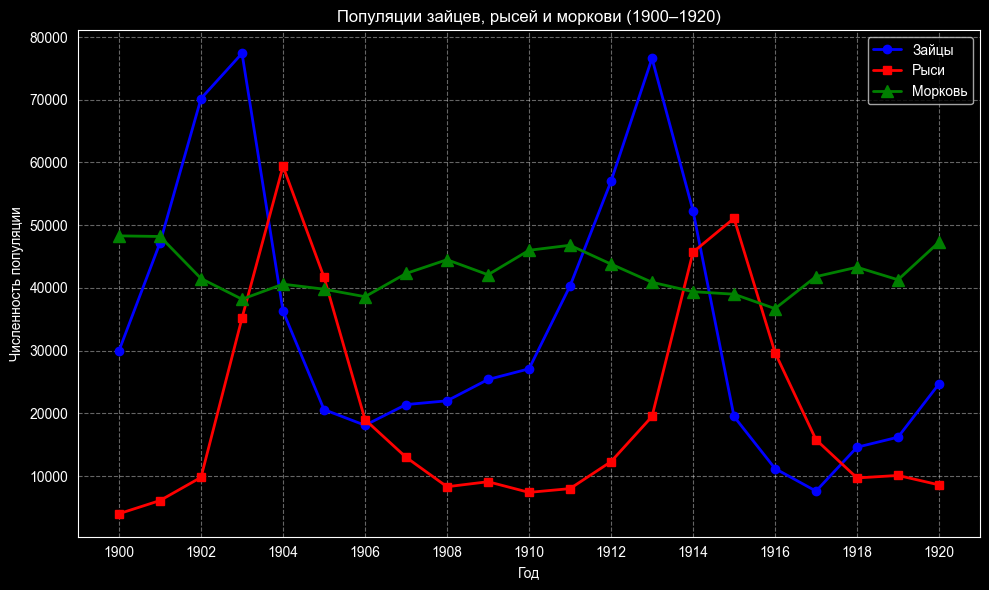

In [6]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("https://lectures.scientific-python.org/_downloads/087d8fe936fcb7a4762b9850b932cf9e/populations.txt")
years = data[:, 0].astype(int)
populations = data[:, 1:]
hares = populations[:, 0]
lynxes = populations[:, 1]
carrots = populations[:, 2]

plt.figure(figsize=(10, 6))
plt.plot(years, hares, 'b-o', label='Зайцы', linewidth=2, markersize=6)
plt.plot(years, lynxes, 'r-s', label='Рыси', linewidth=2, markersize=6)
plt.plot(years, carrots, 'g-^', label='Морковь', linewidth=2, markersize=8)

plt.xlabel('Год')
plt.ylabel('Численность популяции')
plt.title('Популяции зайцев, рысей и моркови (1900–1920)')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.4)
plt.xticks(years[::2])
plt.tight_layout()
plt.show()

- Find which year each species had the largest population. Mark these years in the plot of populations.

Макс. зайцев:   1903 → 77400
Макс. рысей:    1904 → 59400
Макс. моркови:  1900 → 48300


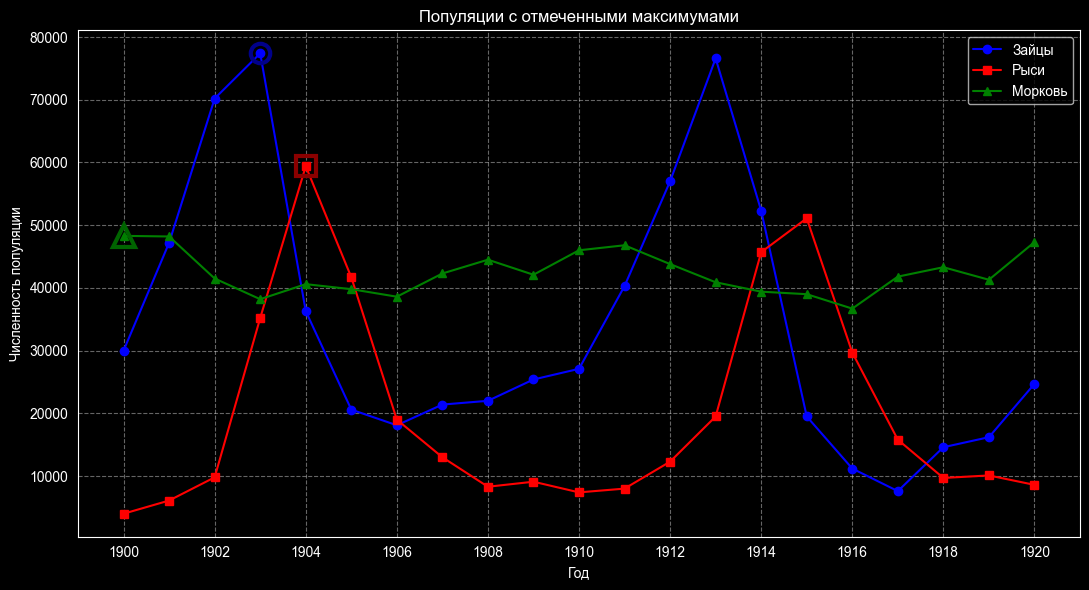

In [9]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("https://lectures.scientific-python.org/_downloads/087d8fe936fcb7a4762b9850b932cf9e/populations.txt")
years = data[:, 0].astype(int)
populations = data[:, 1:]
hares = populations[:, 0]
lynxes = populations[:, 1]
carrots = populations[:, 2]

max_indices = populations.argmax(axis=0)
max_years = years[max_indices]
max_values = populations[max_indices, np.arange(3)]

print("Макс. зайцев:  ", max_years[0], "→", int(max_values[0]))
print("Макс. рысей:   ", max_years[1], "→", int(max_values[1]))
print("Макс. моркови: ", max_years[2], "→", int(max_values[2]))

plt.figure(figsize=(11, 6))
plt.plot(years, hares,   'b-o', label='Зайцы')
plt.plot(years, lynxes,  'r-s', label='Рыси')
plt.plot(years, carrots, 'g-^', label='Морковь')

plt.plot(max_years[0], max_values[0], 'bo', ms=14, mew=3, mfc='none', mec='darkblue')
plt.plot(max_years[1], max_values[1], 'rs', ms=14, mew=3, mfc='none', mec='darkred')
plt.plot(max_years[2], max_values[2], 'g^', ms=16, mew=3, mfc='none', mec='darkgreen')

plt.xlabel('Год')
plt.ylabel('Численность популяции')
plt.title('Популяции с отмеченными максимумами')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.4)
plt.xticks(years[::2])
plt.tight_layout()
plt.show()


- Assuming total population of hares and lynxes is 100%, plot stacked bar graph showing ratio of each specis for each year in the period.

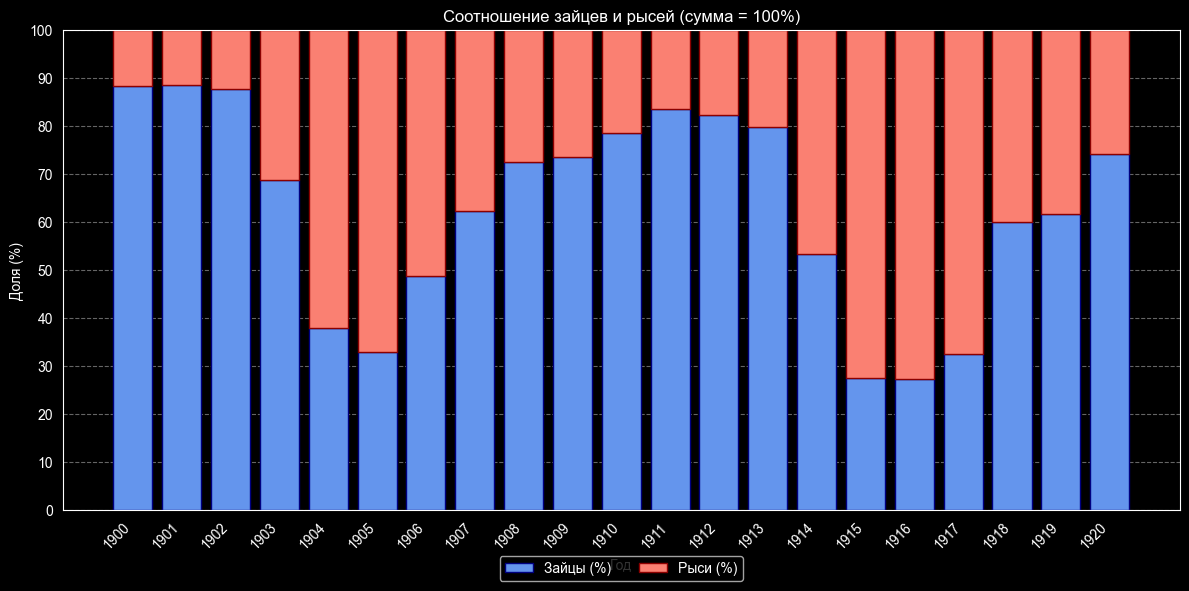

In [10]:
import numpy as np
import matplotlib.pyplot as plt

url = "https://lectures.scientific-python.org/_downloads/087d8fe936fcb7a4762b9850b932cf9e/populations.txt"
data = np.loadtxt(url)

total_hl = hares + lynxes
hares_pct = hares / total_hl * 100
lynxes_pct = lynxes / total_hl * 100

plt.figure(figsize=(12, 6))
plt.bar(years, hares_pct,   color='cornflowerblue', label='Зайцы (%)', edgecolor='navy')
plt.bar(years, lynxes_pct, bottom=hares_pct, color='salmon', label='Рыси (%)', edgecolor='darkred')

plt.xlabel('Год')
plt.ylabel('Доля (%)')
plt.title('Соотношение зайцев и рысей (сумма = 100%)')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=2)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.yticks(np.arange(0, 101, 10))
plt.ylim(0, 100)
plt.xticks(years, rotation=45, ha='right')
plt.tight_layout()
plt.show()


- Find the mean and std of the populations of each species. Plot the historgam of population for each species and show mean values with vertical line. Show each histogram in a separate plot. Arrange 3 plots in a row.

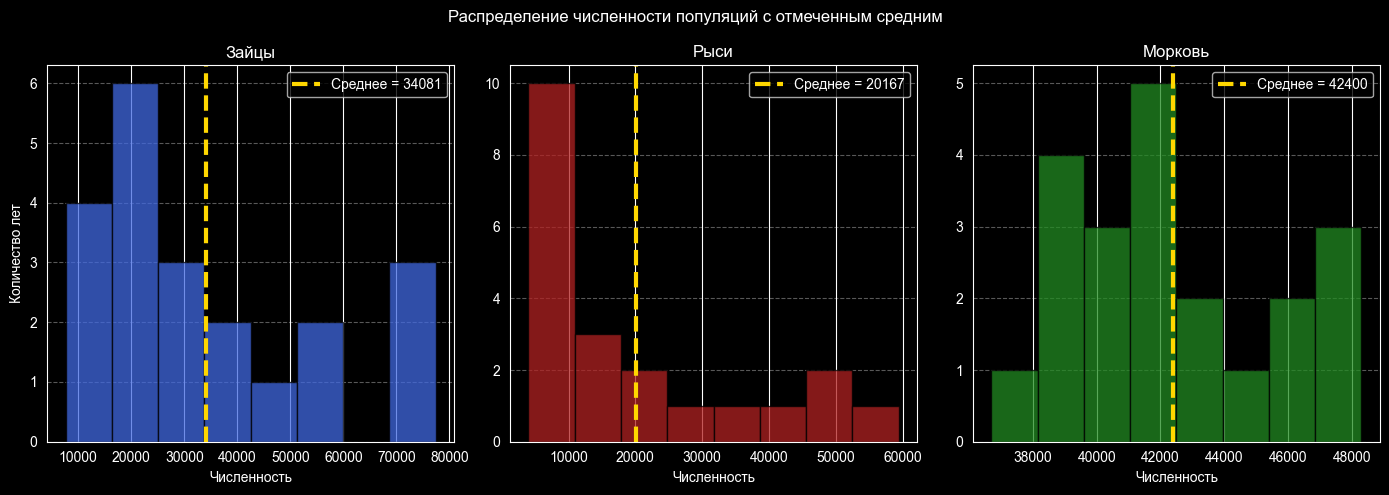

In [11]:
import numpy as np
import matplotlib.pyplot as plt


url = "https://lectures.scientific-python.org/_downloads/087d8fe936fcb7a4762b9850b932cf9e/populations.txt"
data = np.loadtxt(url)

годы    = data[:, 0].astype(int)
зайцы   = data[:, 1]
рыси    = data[:, 2]
морковь = data[:, 3]

means = populations.mean(axis=0)

species = ['Зайцы', 'Рыси', 'Морковь']
colors = ['royalblue', 'firebrick', 'forestgreen']
data_list = [hares, lynxes, carrots]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, (ax, pop, name, col) in enumerate(zip(axes, data_list, species, colors)):
    ax.hist(pop, bins=8, color=col, edgecolor='black', alpha=0.75)
    ax.axvline(means[i], color='gold', lw=3, ls='--', label=f'Среднее = {means[i]:.0f}')
    ax.set_title(name)
    ax.set_xlabel('Численность')
    if i == 0:
        ax.set_ylabel('Количество лет')
    ax.legend(loc='upper right')
    ax.grid(True, axis='y', linestyle='--', alpha=0.35)

fig.suptitle('Распределение численности популяций с отмеченным средним')
plt.tight_layout()
plt.show()


- Find which species (hares or lynxes) has the largest population for each year. Print the result as [H, H, L, H, ...]. Plot a pie chart showing the ratio of "H" and "L" values.

[H, H, H, H, L, L, L, H, H, H, H, H, H, H, H, L, L, L, H, H, H]


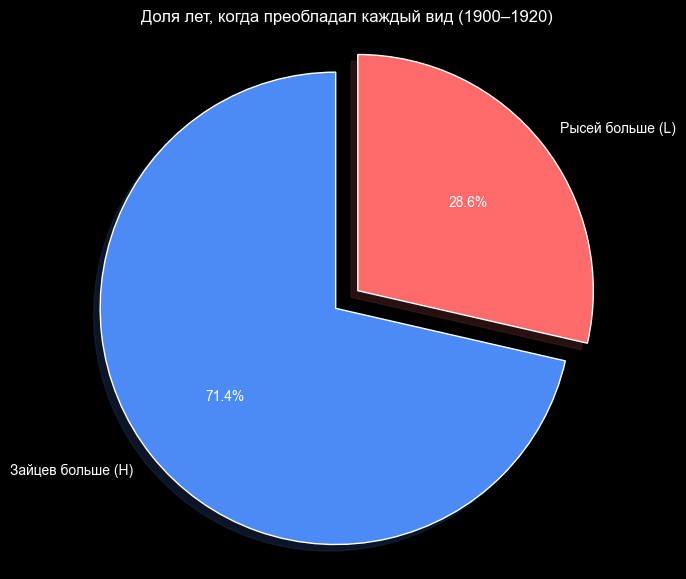

In [14]:
import numpy as np
import matplotlib.pyplot as plt

url = "https://lectures.scientific-python.org/_downloads/087d8fe936fcb7a4762b9850b932cf9e/populations.txt"
data = np.loadtxt(url)

dominant = np.where(hares > lynxes, 'H', 'L')
print("[" + ", ".join(dominant) + "]")

counts = [np.sum(dominant == 'H'), np.sum(dominant == 'L')]

plt.figure(figsize=(7, 7))
plt.pie(counts, labels=['Зайцев больше (H)', 'Рысей больше (L)'],
        colors=['#4c8bf5', '#ff6b6b'], autopct='%1.1f%%',
        startangle=90, explode=[0.06, 0.06], shadow=True)
plt.title('Доля лет, когда преобладал каждый вид (1900–1920)')
plt.axis('equal')
plt.show()


- Plot the change in the hare population and in the lynx population for each year. Find the correlation coefficient between the both time series.

Корреляция изменений: -0.178


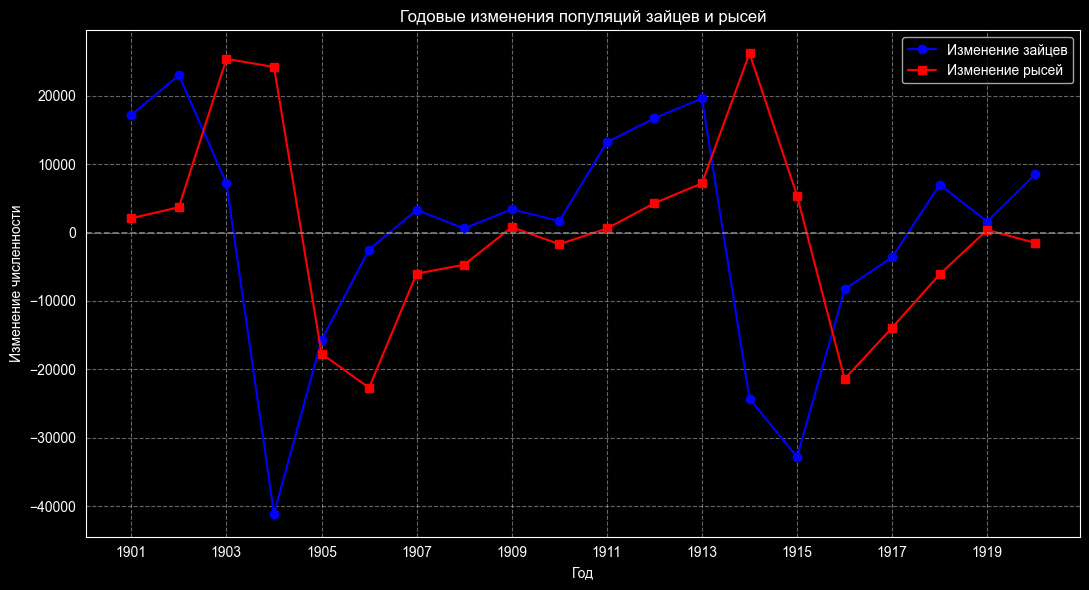

In [15]:
import numpy as np
import matplotlib.pyplot as plt

delta_hares = np.diff(hares)
delta_lynxes = np.diff(lynxes)
years_delta = years[1:]

corr = np.corrcoef(delta_hares, delta_lynxes)[0, 1]
print(f"Корреляция изменений: {corr:.3f}")

plt.figure(figsize=(11, 6))
plt.plot(years_delta, delta_hares,   'b-o', label='Изменение зайцев')
plt.plot(years_delta, delta_lynxes,  'r-s', label='Изменение рысей')
plt.axhline(0, color='gray', ls='--', lw=1.2)

plt.xlabel('Год')
plt.ylabel('Изменение численности')
plt.title('Годовые изменения популяций зайцев и рысей')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.xticks(years_delta[::2])
plt.tight_layout()
plt.show()

- Using a scatter plot, show the population of hares vs lynxes by year (each point corresponds to a particular year, and the point coordinates correspond to the population of the two species in that year).

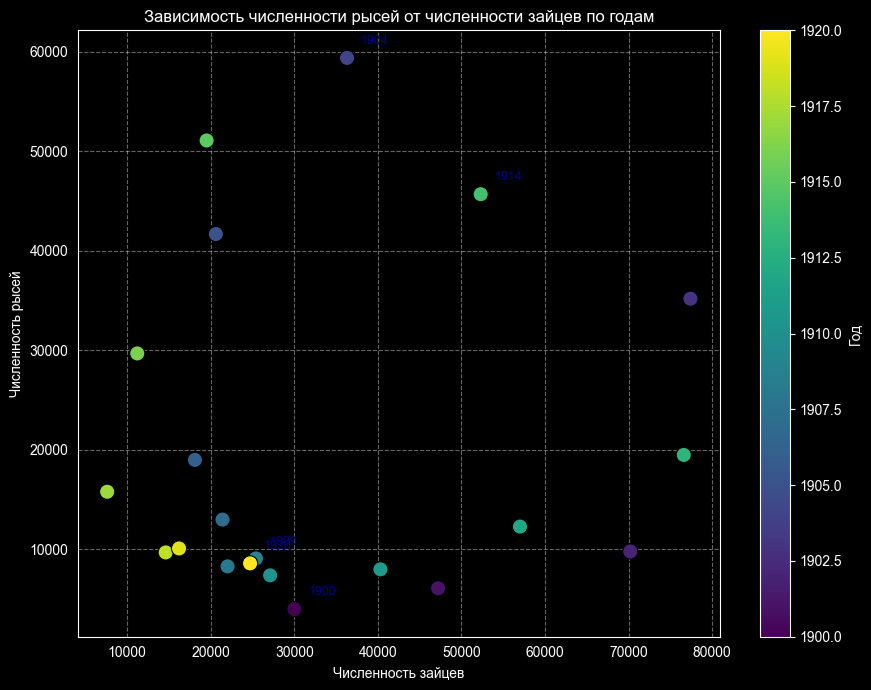

In [16]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("https://lectures.scientific-python.org/_downloads/087d8fe936fcb7a4762b9850b932cf9e/populations.txt")
years = data[:, 0].astype(int)
hares = data[:, 1]
lynxes = data[:, 2]

plt.figure(figsize=(9, 7))
plt.scatter(hares, lynxes, s=120, c=years, cmap='viridis', edgecolor='black', linewidth=0.8)
cbar = plt.colorbar()
cbar.set_label('Год')
for i in [0, 4, 9, 14, 20]:
    plt.annotate(str(years[i]), (hares[i], lynxes[i]),
                 xytext=(10, 10), textcoords='offset points',
                 fontsize=9, color='darkblue')
plt.xlabel('Численность зайцев')
plt.ylabel('Численность рысей')
plt.title('Зависимость численности рысей от численности зайцев по годам')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

- Assume the population of hares in 1920 is unknown. Suggest a way to estimate this value. Compare an estimated value
with the true value and print a ratio of the error to the true value.

In [17]:
import numpy as np

data = np.loadtxt("https://lectures.scientific-python.org/_downloads/087d8fe936fcb7a4762b9850b932cf9e/populations.txt")
years = data[:, 0].astype(int)
hares = data[:, 1]

true_1920 = hares[-1]
recent_changes = np.diff(hares[-6:])
avg_change = np.mean(recent_changes)
estimated_avg = hares[-2] + avg_change

x = years[-6:-1]
y = hares[-6:-1]
slope, intercept = np.polyfit(x, y, 1)
estimated_lin = slope * 1920 + intercept

print(f"Истинное значение зайцев в 1920: {true_1920:.0f}")
print(f"Оценка (среднее изменение):      {estimated_avg:.0f}")
print(f"Оценка (линейная регрессия):    {estimated_lin:.0f}")
print(f"Относительная ошибка (ср. изм.): {abs(estimated_avg - true_1920) / true_1920:.3%}")
print(f"Относительная ошибка (регрессия): {abs(estimated_lin - true_1920) / true_1920:.3%}")

Истинное значение зайцев в 1920: 24700
Оценка (среднее изменение):      17240
Оценка (линейная регрессия):    12860
Относительная ошибка (ср. изм.): 30.202%
Относительная ошибка (регрессия): 47.935%
